<div style="display: flex; align-items: center; justify-content: flex-start; text-align: left;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Logo_universidad_icesi.svg/960px-Logo_universidad_icesi.svg.png" width="300" style="margin-right: 20px;">
    <div>
        <h3 style="margin: 0;">FACULTAD BARBERI DE INGENIERÍA, DISEÑO Y CIENCIAS APLICADAS</h3>
        <h3 style="margin: 0;">ALGORITMOS Y PROGRAMACIÓN III</h3>
    </div>
</div>

# Laboratorio 1: Predicción y Clasificación en la Industria Azucarera

Integrantes:
- ANGY MARIA HURTADO OSORIO A00401755
- HIDEKI TAMURA HERNANDEZ A00348618
- DAVID VERGARA LAVERDE A00XXXXXX


# 1. Carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datasets
df_reg = pd.read_excel("datos/HISTORICO_SUERTES.xlsx")
df_clf = pd.read_excel("datos/BD_IPSA_1940.xlsx")

print("Regresión:", df_reg.shape)
print("Clasificación:", df_clf.shape)

Regresión: (21027, 85)
Clasificación: (2187, 21)


# 2. Exploración inicial

## 2.1 Vista general de los datos

### Regresión:

In [4]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Período                    21027 non-null  int64         
 1   Hacienda                   21027 non-null  int64         
 2   Nombre                     21027 non-null  object        
 3   Zona                       21027 non-null  object        
 4   Tenencia                   21026 non-null  float64       
 5   Suerte                     21027 non-null  object        
 6   Suelo                      17269 non-null  object        
 7   Area Neta                  21027 non-null  float64       
 8   Dist Km                    21022 non-null  float64       
 9   Variedad                   21027 non-null  object        
 10  Cod.Estado #               21027 non-null  int64         
 11  Cod.Estado                 21027 non-null  object        
 12  F.Si

### Clasificación:

In [5]:
df_clf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      2187 non-null   int64  
 1   NOME            2187 non-null   object 
 2   FAZ             2187 non-null   int64  
 3   TAL             2187 non-null   object 
 4   tipocorte       2187 non-null   object 
 5   variedad        2187 non-null   object 
 6   madurada        2187 non-null   object 
 7   producto        2187 non-null   object 
 8   dosismad        2187 non-null   float64
 9   semsmad         2187 non-null   float64
 10  edad            2187 non-null   float64
 11  cortes          2187 non-null   int64  
 12  me              2187 non-null   float64
 13  vejez           2187 non-null   float64
 14  sacarosa        2187 non-null   float64
 15  mes             2187 non-null   int64  
 16  periodo         2187 non-null   int64  
 17  TCH             2187 non-null   i

## 2.2 Tipos de datos y descripción

### Regresión:

In [6]:
df_reg.head()

,Período,Hacienda,Nombre,Zona,Tenencia,Suerte,Suelo,Area Neta,Dist Km,Variedad,...,Humedad Rel Media Ciclo,Oscilacion Temp Med 0-3,Oscilacion Temp Ciclo,Sum Oscilacion Temp Ciclo,Radicion Solar 0-3,Radiacion Solar Ciclo,Precipitacion 0_3,Precipitacion Ciclo,Evaporacion 0-3,Evaporacion Ciclo
0,201701,80493,LA CONCHA,IP02,51.0,002A,CANTARINA,6.00,4.3,CC85-92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,201701,81284,UKRANIA INCAUCA,IP05,81.0,039B,NaN,1.45,NaN,CC85-92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201701,80203,EL AMPARO SAA,IP05,31.0,007,CORINTIAS,8.24,23.0,CC01-1228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,201701,81380,SAN JUDAS INCAUCA,IP05,82.0,013A,NaN,1.05,66.5,CC01-1940,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,201701,80298,JAVA,IP06,31.0,025A,GALPON,4.53,17.0,RB73-2223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Clasificación:

In [7]:
df_clf.head()

,Unnamed: 0,NOME,FAZ,TAL,tipocorte,variedad,madurada,producto,dosismad,semsmad,...,cortes,me,vejez,sacarosa,mes,periodo,TCH,lluvias,grupo_tenencia,pct_diatrea
0,11,AMAIME SILCA,81291,40,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,8.3,...,4,12.7,2.4,14.0,12,202012,112,137,3,6.2
1,12,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.3,...,2,7.8,2.3,13.0,3,201903,157,0,3,3.5
2,13,AMAIME SILCA,81291,41,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,7.9,...,3,8.8,1.8,13.3,3,202003,167,68,3,4.3
3,15,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.8,6.6,...,1,6.1,2.5,13.4,3,201903,156,0,3,3.5
4,16,AMAIME SILCA,81291,43,Mecanizado Verde,CC01-1940,SI,BONUS 250 EC REGULADOR FISIOLÓGICO,0.6,8.1,...,2,7.9,2.1,14.0,3,202003,151,68,3,4.3


# 3. Análisis de datos faltantes

## 3.0 Exclusión de variables con data leakage

Antes de analizar nulos, se excluyen las variables que son métricas derivadas de las variables objetivo o que se conocen únicamente después de la cosecha. Incluirlas como predictores genera fuga de información (*data leakage*) y produce modelos con rendimiento artificialmente inflado que no funcionarían en producción.

In [8]:
# Variables que NO pueden usarse como predictores — data leakage
# HISTORICO_SUERTES: derivadas de TCH o %Sac.Caña, o calculadas post-cosecha
LEAKAGE_REG = ['TonUltCorte', 'TCHM', 'Ton.Azucar', 'Rdto',
               'TAH', 'TAHM', '%ATR', 'KATRHM', '%Sac.Muestreadora']

# BD_IPSA_1940: derivadas de TCH o sacarosa
LEAKAGE_CLF = ['TAH', 'TAHM', 'TCHM', 'KATRHM', 'Rdto', '%Sac.Muestreadora']

# Nota: TCH, %Sac.Caña y sacarosa son los targets — se tratan por separado

print("Leakage a excluir en HISTORICO_SUERTES:")
print(" ", [c for c in LEAKAGE_REG if c in df_reg.columns])
print("\nLeakage a excluir en BD_IPSA_1940:")
print(" ", [c for c in LEAKAGE_CLF if c in df_clf.columns])

Leakage a excluir en HISTORICO_SUERTES:
  ['TonUltCorte', 'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', '%ATR', 'KATRHM', '%Sac.Muestreadora']

Leakage a excluir en BD_IPSA_1940:
  []


## 3.1 Porcentaje de valores nulos

Se calcula el porcentaje de valores faltantes por columna en ambos datasets para decidir entre imputar o descartar cada variable.

In [9]:
def reporte_nulos(df, nombre):
    """Tabla de nulos ordenada de mayor a menor porcentaje."""
    nulos  = df.isnull().sum()
    pct    = (nulos / len(df) * 100).round(2)
    reporte = pd.DataFrame({
        'Nulos'      : nulos,
        '% Faltante' : pct,
        'Dtype'      : df.dtypes
    }).query('Nulos > 0').sort_values('% Faltante', ascending=False)
    print(f"\n{'='*55}")
    print(f"Dataset: {nombre}  |  Filas: {len(df)}  |  Cols: {df.shape[1]}")
    print(f"{'='*55}")
    if reporte.empty:
        print("  → Sin valores nulos detectados.")
    else:
        print(reporte.to_string())
    return reporte

nulos_reg = reporte_nulos(df_reg, "HISTORICO_SUERTES")
nulos_clf = reporte_nulos(df_clf, "BD_IPSA_1940")


Dataset: HISTORICO_SUERTES  |  Filas: 21027  |  Cols: 85
                           Nulos  % Faltante           Dtype
Sum Oscilacion Temp Ciclo  21027      100.00         float64
Fert.Nitrogen.             21027      100.00         float64
Urea 46%                   20304       96.56         float64
NITRAX-S                   20279       96.44         float64
MEZ                        20056       95.38         float64
MicroZinc                  19878       94.54         float64
Boro Granul.               19742       93.89         float64
Sul.Amonio                 19670       93.55         float64
NITO_XTEND                 17348       82.50         float64
Vinaza                     16929       80.51         float64
Oscilacion Temp Ciclo      16497       78.46         float64
Oscilacion Temp Med 0-3    16497       78.46         float64
Radicion Solar 0-3         16497       78.46         float64
Temp. Media Ciclo          16497       78.46         float64
Temp Max Ciclo             

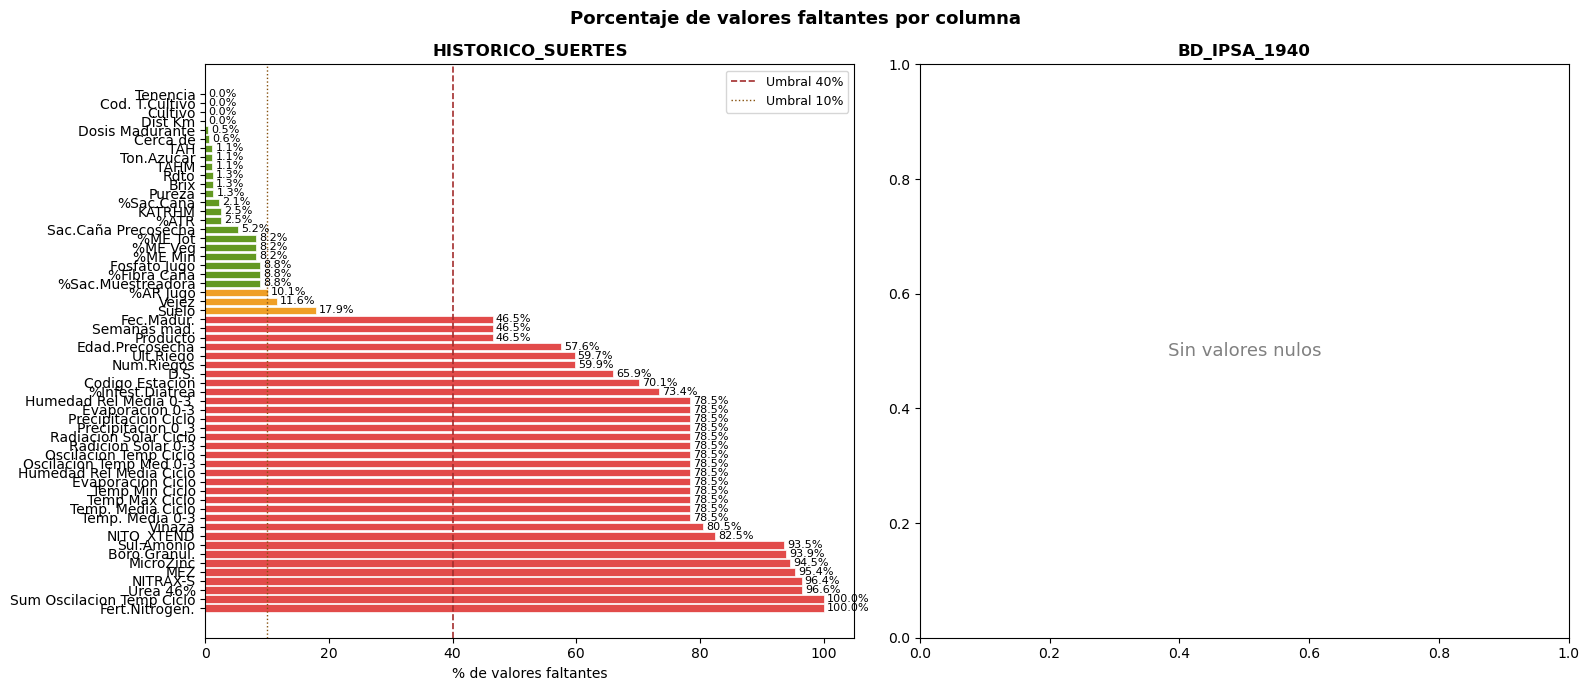

Verde: < 10% | Naranja: 10-40% | Rojo: > 40% (candidato a descartar)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (df, nombre) in zip(axes, [(df_reg, "HISTORICO_SUERTES"),
                                    (df_clf, "BD_IPSA_1940")]):
    pct_nulos = (df.isnull().mean() * 100).sort_values(ascending=False)
    pct_nulos = pct_nulos[pct_nulos > 0]

    if pct_nulos.empty:
        ax.text(0.5, 0.5, "Sin valores nulos", ha="center", va="center",
                transform=ax.transAxes, fontsize=13, color="gray")
        ax.set_title(nombre, fontweight='bold')
        continue

    colores = ['#E24B4A' if p > 40 else '#EF9F27' if p > 10 else '#639922'
               for p in pct_nulos]
    bars = ax.barh(pct_nulos.index, pct_nulos.values,
                   color=colores, edgecolor='white', linewidth=0.5)
    ax.axvline(x=40, color='#A32D2D', linestyle='--', linewidth=1.2, label='Umbral 40%')
    ax.axvline(x=10, color='#854F0B', linestyle=':',  linewidth=1.0, label='Umbral 10%')
    ax.set_xlabel('% de valores faltantes')
    ax.set_title(nombre, fontweight='bold')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, pct_nulos.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle("Porcentaje de valores faltantes por columna", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nulos_por_columna.png', dpi=150, bbox_inches='tight')
plt.show()
print("Verde: < 10% | Naranja: 10-40% | Rojo: > 40% (candidato a descartar)")

## 3.2 BD_IPSA_1940 — Sin valores nulos

El dataset BD_IPSA_1940 **no presenta valores nulos** en ninguna de sus columnas. Sin embargo, durante el diagnóstico se detectaron **2 valores negativos en `semsmad`** (semanas de maduración), lo cual no tiene sentido agronómico. Se corrigen con `clip(lower=0)`. El resto del preprocesamiento de este dataset (exclusión de leakage, codificación de categóricas y división train/test) se realiza en la Sección 5.

In [11]:
df_clf_clean = df_clf.copy()

# Excluir leakage
cols_drop_clf = [c for c in LEAKAGE_CLF if c in df_clf_clean.columns]
df_clf_clean.drop(columns=cols_drop_clf, inplace=True)
print(f"Leakage eliminado: {cols_drop_clf}")

# Corregir negativos en semsmad
if 'semsmad' in df_clf_clean.columns:
    neg = (df_clf_clean['semsmad'] < 0).sum()
    df_clf_clean['semsmad'] = df_clf_clean['semsmad'].clip(lower=0)
    print(f"'semsmad': {neg} valores negativos → corregidos a 0")

print(f"\nNulos en BD_IPSA_1940: {df_clf_clean.isnull().sum().sum()}")
print(f"Shape: {df_clf_clean.shape}")

Leakage eliminado: []
'semsmad': 2 valores negativos → corregidos a 0

Nulos en BD_IPSA_1940: 0
Shape: (2187, 21)


## 3.3 HISTORICO_SUERTES — Estrategia de imputación

Este dataset sí presenta valores faltantes. La estrategia se define según el contexto agronómico, no solo por criterio estadístico:

| Criterio | Decisión | Justificación |
|---|---|---|
| **% nulos > 40 %** | Descartar columna | Imputar con alta incertidumbre introduce más ruido que información |
| **Variable objetivo sin valor** | Eliminar fila | No se puede entrenar ni evaluar un modelo sin el target |
| **`Dosis Madurante` / `Semanas mad.` = NaN** | Imputar con **0** | Ausencia de registro indica que no se aplicó madurante |
| **Numéricas restantes** | Mediana por **Zona** + global como fallback | Controla la variabilidad espacial del valle del río Cauca |
| **Categóricas** | Categoría `'Desconocido'` | Preserva la fila y señaliza la ausencia explícitamente |

In [13]:
df_reg_clean = df_reg.copy()
UMBRAL = 40

# 1. Excluir leakage 
cols_drop_leakage = [c for c in LEAKAGE_REG if c in df_reg_clean.columns]
df_reg_clean.drop(columns=cols_drop_leakage, inplace=True)
print(f"[1] Leakage eliminado ({len(cols_drop_leakage)} cols): {cols_drop_leakage}")

# 2. Descartar columnas con > 40 % nulos
pct_cols = (df_reg_clean.isnull().mean() * 100)
cols_drop_umbral = pct_cols[pct_cols > UMBRAL].index.tolist()
df_reg_clean.drop(columns=cols_drop_umbral, inplace=True)
print(f"[2] Descartadas por >{UMBRAL}% nulos ({len(cols_drop_umbral)} cols): {cols_drop_umbral}")

# 3. Eliminar filas sin target
# %Sac.Caña tenía 449 nulos — no se imputa, se eliminan las filas
targets_reg = ['TCH', '%Sac.Caña']
filas_antes = len(df_reg_clean)
df_reg_clean.dropna(subset=[t for t in targets_reg if t in df_reg_clean.columns], inplace=True)
eliminadas  = filas_antes - len(df_reg_clean)
print(f"[3] Filas eliminadas por target nulo: {eliminadas} "
      f"({filas_antes} → {len(df_reg_clean)}, {eliminadas/filas_antes*100:.1f}% del total)")

# 4. Dosis Madurante y Semanas mad → 0
for col in ['Dosis Madurante', 'Semanas mad.']:
    if col in df_reg_clean.columns and df_reg_clean[col].isnull().sum() > 0:
        n = df_reg_clean[col].isnull().sum()
        df_reg_clean[col] = df_reg_clean[col].fillna(0)
        print(f"[4] '{col}': {n} nulos → 0 (no se aplicó madurante)")

# 5. Numéricas restantes → mediana por Zona + global fallback
cols_num = [c for c in df_reg_clean.select_dtypes(include='number').columns
            if c not in targets_reg]
for col in cols_num:
    if df_reg_clean[col].isnull().sum() > 0:
        n = df_reg_clean[col].isnull().sum()
        if 'Zona' in df_reg_clean.columns:
            df_reg_clean[col] = df_reg_clean.groupby('Zona')[col].transform(
                lambda x: x.fillna(x.median()))
        df_reg_clean[col] = df_reg_clean[col].fillna(df_reg_clean[col].median())
        print(f"[5] '{col}': {n} nulos → mediana por Zona")

# 6. Categóricas → 'Desconocido'
for col in df_reg_clean.select_dtypes(include='object').columns:
    if df_reg_clean[col].isnull().sum() > 0:
        n = df_reg_clean[col].isnull().sum()
        df_reg_clean[col] = df_reg_clean[col].fillna('Desconocido')
        print(f"[6] '{col}': {n} nulos → 'Desconocido'")

print(f"\n→ Nulos restantes: {df_reg_clean.isnull().sum().sum()}")
print(f"→ Shape final: {df_reg_clean.shape}")

[1] Leakage eliminado (9 cols): ['TonUltCorte', 'TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', '%ATR', 'KATRHM', '%Sac.Muestreadora']
[2] Descartadas por >40% nulos (33 cols): ['D.S.', 'Ult.Riego', 'Fec.Madur.', 'Producto', 'Semanas mad.', 'Edad.Precosecha', 'Num.Riegos', '%Infest.Diatrea', 'Fert.Nitrogen.', 'Urea 46%', 'MEZ', 'Boro Granul.', 'MicroZinc', 'NITO_XTEND', 'Sul.Amonio', 'NITRAX-S', 'Vinaza', 'Codigo Estacion', 'Temp. Media 0-3', 'Temp. Media Ciclo', 'Temp Max Ciclo', 'Temp Min Ciclo', 'Humedad Rel Media 0-3 ', 'Humedad Rel Media Ciclo', 'Oscilacion Temp Med 0-3', 'Oscilacion Temp Ciclo', 'Sum Oscilacion Temp Ciclo', 'Radicion Solar 0-3', 'Radiacion Solar Ciclo', 'Precipitacion 0_3', 'Precipitacion Ciclo', 'Evaporacion 0-3', 'Evaporacion Ciclo']
[3] Filas eliminadas por target nulo: 449 (21027 → 20578, 2.1% del total)
[4] 'Dosis Madurante': 96 nulos → 0 (no se aplicó madurante)
[5] 'Tenencia': 1 nulos → mediana por Zona
[5] 'Dist Km': 5 nulos → mediana por Zona
[5] 'Cod. T.Cu

## 3.4 Verificación final

  VERIFICACIÓN FINAL — POST IMPUTACIÓN
  HISTORICO_SUERTES : (20578, 43)  | Nulos: 0
  BD_IPSA_1940      : (2187, 21)   | Nulos: 0


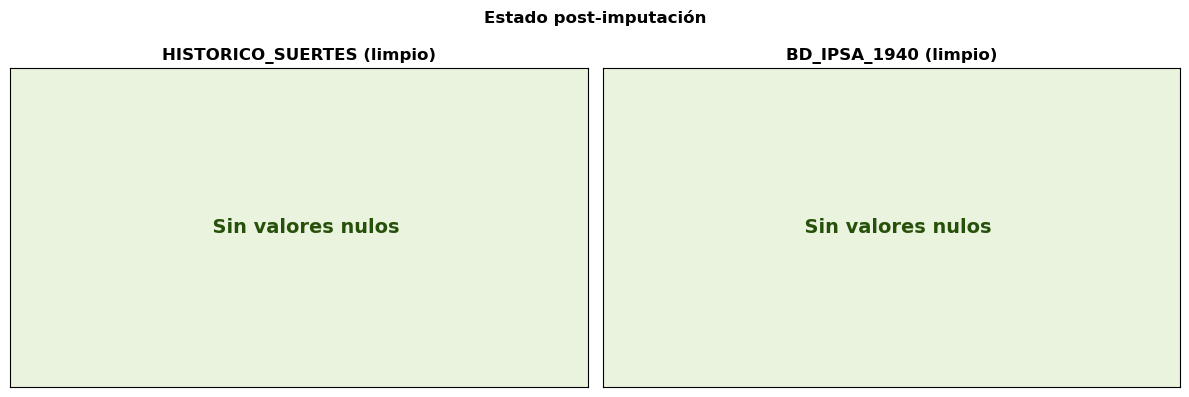

In [15]:
print("=" * 55)
print("  VERIFICACIÓN FINAL — POST IMPUTACIÓN")
print("=" * 55)
print(f"  HISTORICO_SUERTES : {df_reg_clean.shape}  | Nulos: {df_reg_clean.isnull().sum().sum()}")
print(f"  BD_IPSA_1940      : {df_clf_clean.shape}   | Nulos: {df_clf_clean.isnull().sum().sum()}")
print("=" * 55)

# Confirmación visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, nombre) in zip(axes, [(df_reg_clean, "HISTORICO_SUERTES (limpio)"),
                                    (df_clf_clean,  "BD_IPSA_1940 (limpio)")]):
    pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    pct = pct[pct > 0]
    if pct.empty:
        ax.text(0.5, 0.5, "  Sin valores nulos", ha="center", va="center",
                transform=ax.transAxes, fontsize=14,
                color="#27500A", fontweight="bold")
        ax.set_facecolor("#EAF3DE")
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax.barh(pct.index, pct.values, color="#E24B4A")
        ax.set_xlabel("% nulos restantes")
    ax.set_title(nombre, fontweight="bold")

plt.suptitle("Estado post-imputación", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 4. Análisis exploratorio de datos (EDA)

## 4.1 Distribución de variables

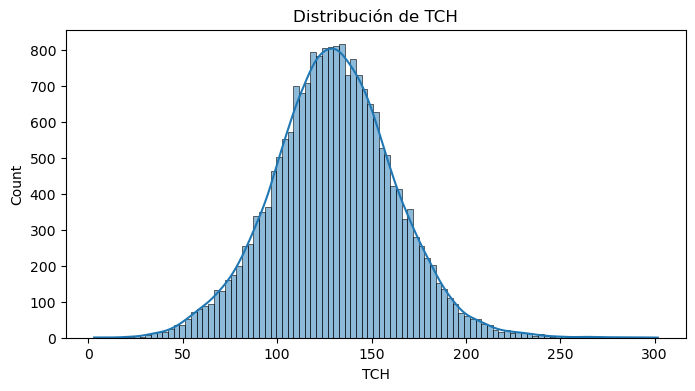

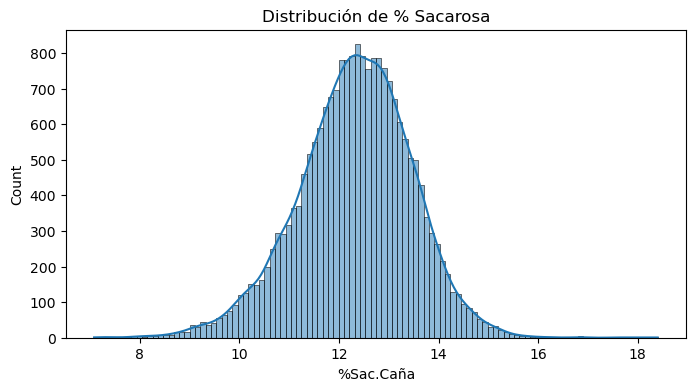

In [16]:
# Distribución TCH
plt.figure(figsize=(8,4))
sns.histplot(df_reg_clean["TCH"], kde=True)
plt.title("Distribución de TCH")
plt.xlabel("TCH")
plt.show()

# Distribución Sacarosa
plt.figure(figsize=(8,4))
sns.histplot(df_reg_clean["%Sac.Caña"], kde=True)
plt.title("Distribución de % Sacarosa")
plt.xlabel("%Sac.Caña")
plt.show()

## 4.2 Detección de outliers


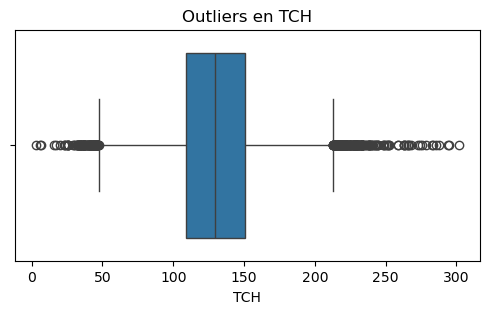

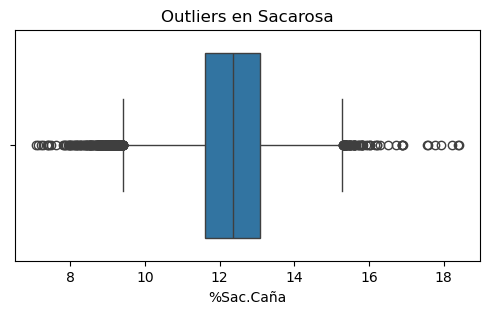

In [17]:
# Boxplot TCH
plt.figure(figsize=(6,3))
sns.boxplot(x=df_reg_clean["TCH"])
plt.title("Outliers en TCH")
plt.show()

# Boxplot Sacarosa
plt.figure(figsize=(6,3))
sns.boxplot(x=df_reg_clean["%Sac.Caña"])
plt.title("Outliers en Sacarosa")
plt.show()

## 4.3 Correlaciones

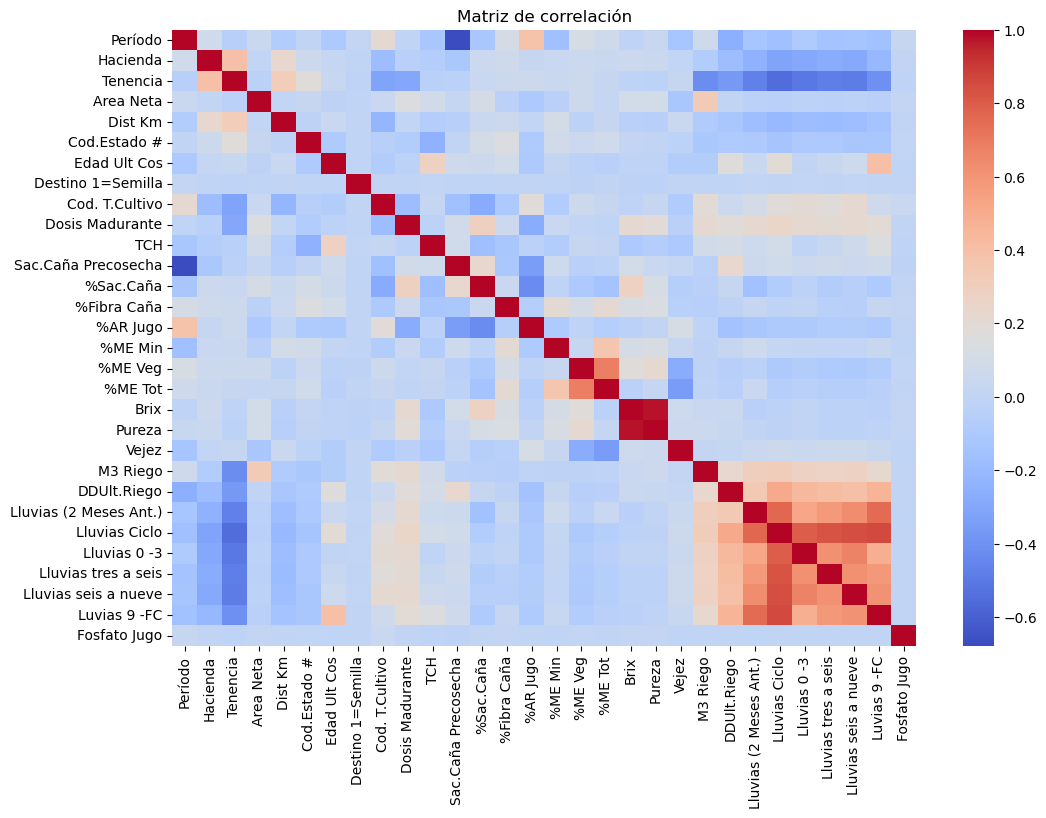

In [18]:
# Solo variables numéricas
corr = df_reg_clean.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Matriz de correlación")
plt.show()

In [19]:
corr_TCH = corr["TCH"].sort_values(ascending=False)
print("Top variables correlacionadas con TCH:")
print(corr_TCH.head(10))

corr_Sac = corr["%Sac.Caña"].sort_values(ascending=False)
print("\nTop variables correlacionadas con Sacarosa:")
print(corr_Sac.head(10))

Top variables correlacionadas con TCH:
TCH                       1.000000
Edad Ult Cos              0.280524
Luvias 9 -FC              0.153096
DDUlt.Riego               0.096214
Lluvias Ciclo             0.090787
M3 Riego                  0.088029
Area Neta                 0.086959
Sac.Caña Precosecha       0.081603
Lluvias seis a nueve      0.072360
Lluvias (2 Meses Ant.)    0.065856
Name: TCH, dtype: float64

Top variables correlacionadas con Sacarosa:
%Sac.Caña              1.000000
Dosis Madurante        0.288457
Brix                   0.278750
Sac.Caña Precosecha    0.229455
Pureza                 0.121478
Area Neta              0.113064
Cod.Estado #           0.098363
Edad Ult Cos           0.059867
Hacienda               0.050982
Dist Km                0.048025
Name: %Sac.Caña, dtype: float64


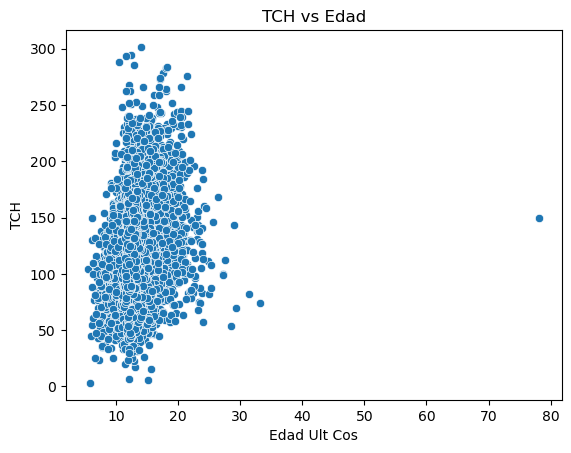

In [20]:
# TCH vs Edad
if "Edad Ult Cos" in df_reg_clean.columns:
    sns.scatterplot(x=df_reg_clean["Edad Ult Cos"], y=df_reg_clean["TCH"])
    plt.title("TCH vs Edad")
    plt.show()

# Sacarosa vs Lluvias (si existe)
if "lluvias" in df_reg_clean.columns:
    sns.scatterplot(x=df_reg_clean["lluvias"], y=df_reg_clean["%Sac.Caña"])
    plt.title("Sacarosa vs Lluvias")
    plt.show()

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Seleccionar variables numéricas sin target
X = df_reg_clean.select_dtypes(include=np.number).drop(columns=["TCH", "%Sac.Caña"], errors='ignore')

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                  Variable           VIF
22           Lluvias Ciclo  1.119604e+06
26            Luvias 9 -FC  1.589282e+05
23            Lluvias 0 -3  6.852287e+04
24     Lluvias tres a seis  6.705408e+04
25    Lluvias seis a nueve  6.491713e+04
1                 Hacienda  2.388899e+04
0                  Período  2.387965e+04
17                  Pureza  3.182024e+02
16                    Brix  3.050551e+02
11             %Fibra Caña  7.626454e+01
6             Edad Ult Cos  7.617603e+01
8           Cod. T.Cultivo  4.812145e+01
15                 %ME Tot  4.099267e+01
14                 %ME Veg  1.860766e+01
12                %AR Jugo  1.503326e+01
2                 Tenencia  1.263186e+01
21  Lluvias (2 Meses Ant.)  5.328424e+00
4                  Dist Km  3.519834e+00
3                Area Neta  3.067929e+00
9          Dosis Madurante  2.897231e+00
10     Sac.Caña Precosecha  2.324202e+00
5             Cod.Estado #  2.314270e+00
13                 %ME Min  2.095159e+00
20             D

## 4.4 Relaciones entre variables

# 5. Preprocesamiento

## 5.1 Limpieza de datos

## 5.2 Codificación de variables

## 5.3 Selección de variables

## 5.4 División en entrenamiento y prueba

# 6. Modelos de regresión

## 6.1 Regresión lineal

## 6.2 Modelo avanzado (Random Forest / XGBoost)

## 6.3 Evaluación de modelos

# 7. Modelos de clasificación

## 7.1 Creación de categorías (alto, medio, bajo)

## 7.2 Regresión logística

## 7.3 K-Nearest Neighbors (KNN)

## 7.4 Modelo avanzado

## 7.5 Evaluación de modelos

# 8. Validación y ajuste de modelos

## 8.1 Validación cruzada

## 8.2 Ajuste de hiperparámetros

# 9. Resultados finales

## 9.1 Comparación de modelos

## 9.2 Visualizaciones

- Valores reales vs predichos
- Matrices de confusión
- Importancia de variables

# 10. Conclusiones
